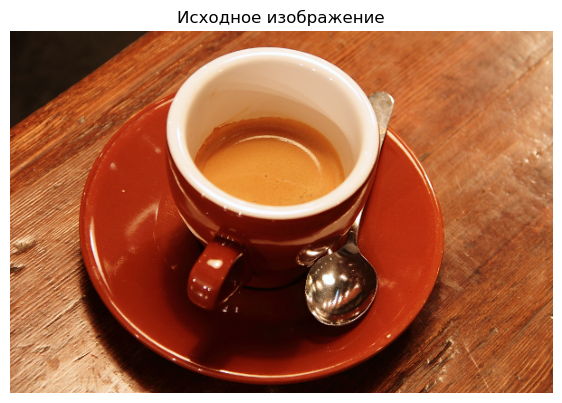

In [10]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data

np.random.seed(42)

image_rgb = data.coffee()
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(7, 5))
plt.imshow(image_rgb)
plt.title('Исходное изображение')
plt.axis('off')
plt.show()

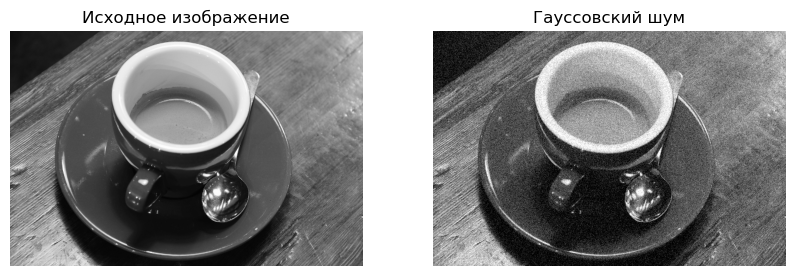

In [2]:
mean = 0
sigma = 20

gaussian_noise = np.random.normal(mean, sigma, image_gray.shape)
gaussian_image = image_gray.astype(np.float32) + gaussian_noise
gaussian_image = np.clip(gaussian_image, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')
plt.show()

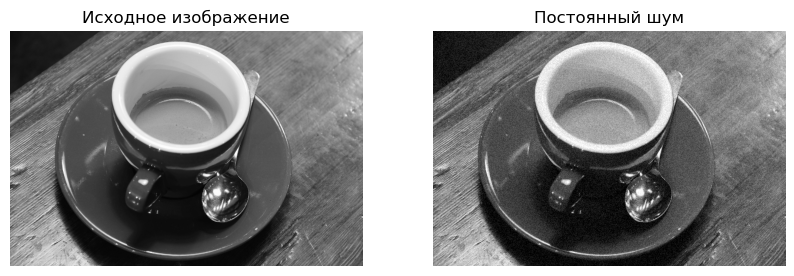

In [3]:
min_noise = -20
max_noise = 20

uniform_noise = np.random.uniform(min_noise, max_noise, image_gray.shape)
uniform_image = image_gray.astype(np.float32) + uniform_noise
uniform_image = np.clip(uniform_image, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(uniform_image, cmap='gray')
plt.title('Постоянный шум')
plt.axis('off')
plt.show()

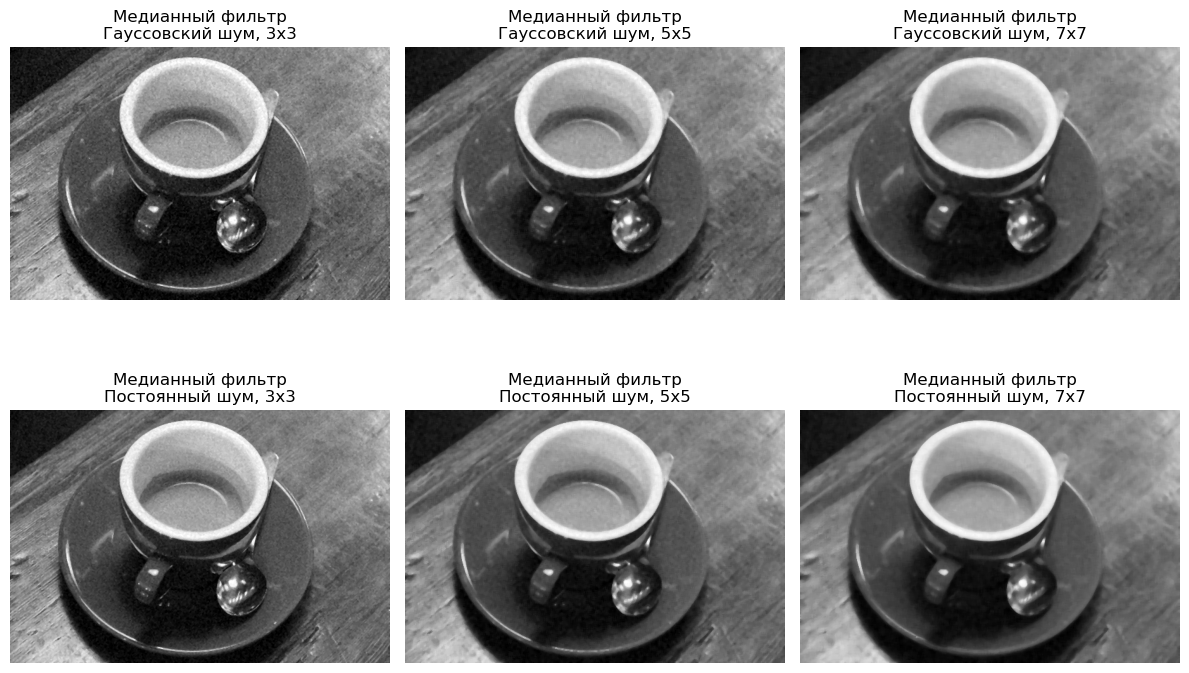

In [4]:
# Медианный фильтр

median_3 = cv2.medianBlur(gaussian_image, 3)
median_5 = cv2.medianBlur(gaussian_image, 5)
median_7 = cv2.medianBlur(gaussian_image, 7)

uniform_median_3 = cv2.medianBlur(uniform_image, 3)
uniform_median_5 = cv2.medianBlur(uniform_image, 5)
uniform_median_7 = cv2.medianBlur(uniform_image, 7)

plt.figure(figsize=(12, 8))
for i, (img, title) in enumerate([
    (median_3, 'Гауссовский шум, 3x3'),
    (median_5, 'Гауссовский шум, 5x5'),
    (median_7, 'Гауссовский шум, 7x7'),
    (uniform_median_3, 'Постоянный шум, 3x3'),
    (uniform_median_5, 'Постоянный шум, 5x5'),
    (uniform_median_7, 'Постоянный шум, 7x7')
], 1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap='gray')
    plt.title('Медианный фильтр\n' + title)
    plt.axis('off')
plt.tight_layout()
plt.show()

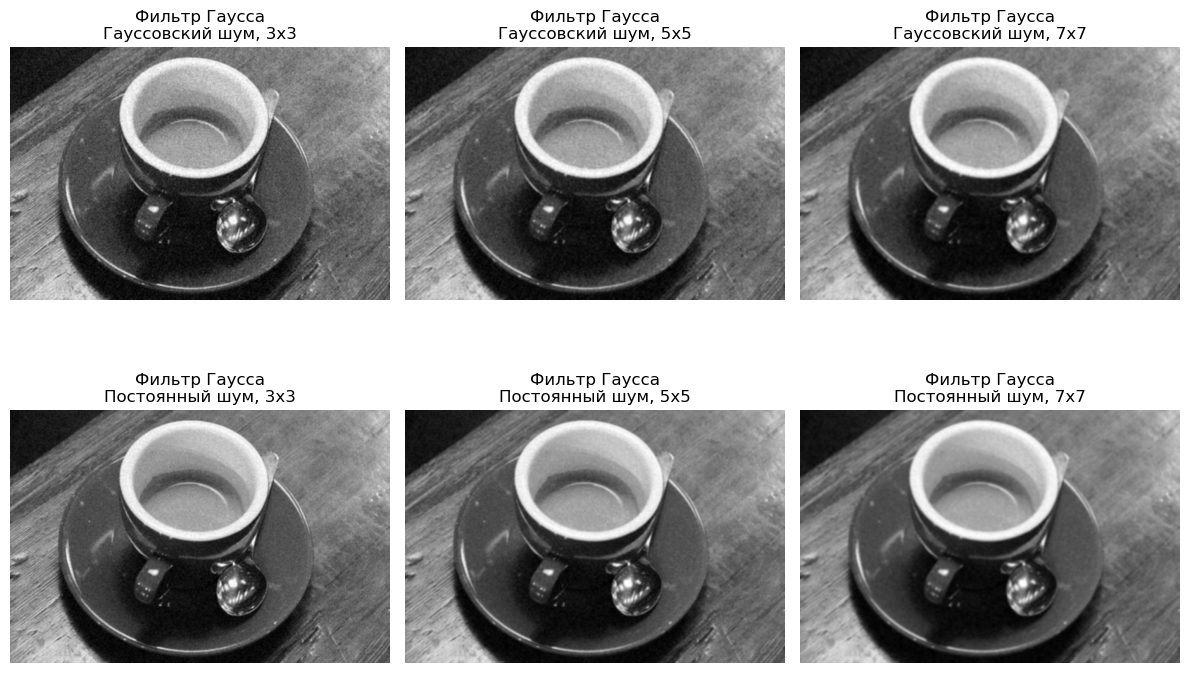

In [5]:
# Фильтр Гаусса

gauss_3 = cv2.GaussianBlur(gaussian_image, (3, 3), 0)
gauss_5 = cv2.GaussianBlur(gaussian_image, (5, 5), 0)
gauss_7 = cv2.GaussianBlur(gaussian_image, (7, 7), 0)

uniform_gauss_3 = cv2.GaussianBlur(uniform_image, (3, 3), 0)
uniform_gauss_5 = cv2.GaussianBlur(uniform_image, (5, 5), 0)
uniform_gauss_7 = cv2.GaussianBlur(uniform_image, (7, 7), 0)

plt.figure(figsize=(12, 8))
for i, (img, title) in enumerate([
    (gauss_3, 'Гауссовский шум, 3x3'),
    (gauss_5, 'Гауссовский шум, 5x5'),
    (gauss_7, 'Гауссовский шум, 7x7'),
    (uniform_gauss_3, 'Постоянный шум, 3x3'),
    (uniform_gauss_5, 'Постоянный шум, 5x5'),
    (uniform_gauss_7, 'Постоянный шум, 7x7')
], 1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap='gray')
    plt.title('Фильтр Гаусса\n' + title)
    plt.axis('off')
plt.tight_layout()
plt.show()

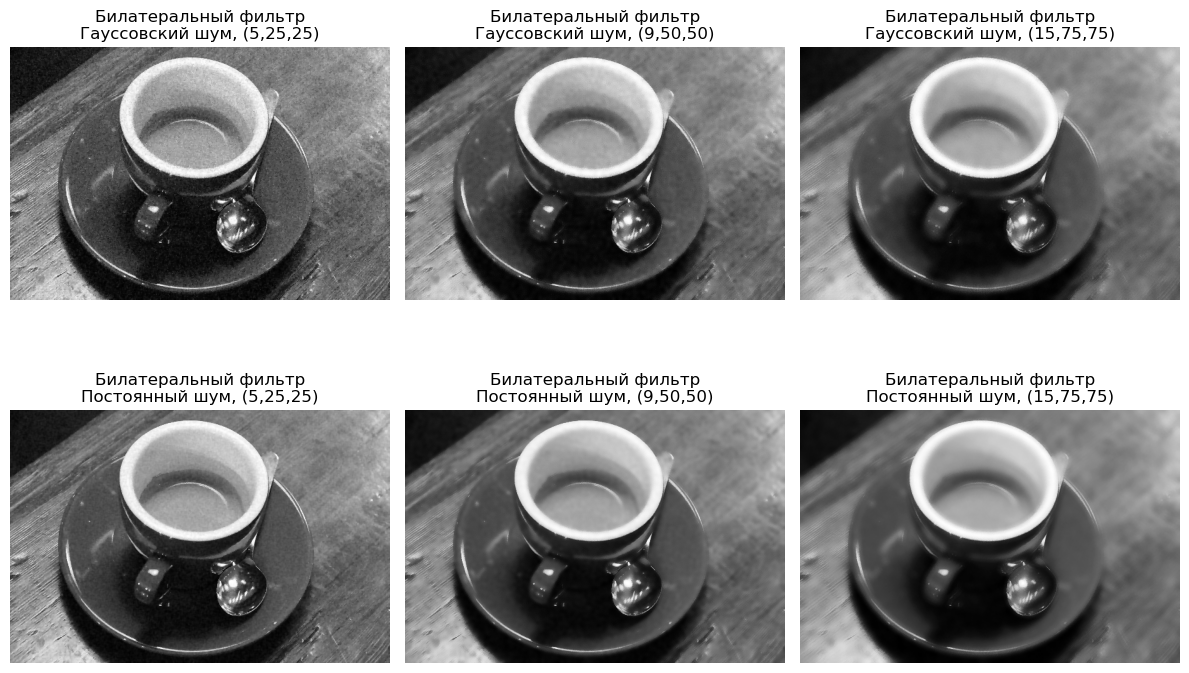

In [6]:
# Билатеральный фильтр

bilateral_1 = cv2.bilateralFilter(gaussian_image, 5, 25, 25)
bilateral_2 = cv2.bilateralFilter(gaussian_image, 9, 50, 50)
bilateral_3 = cv2.bilateralFilter(gaussian_image, 15, 75, 75)

uniform_bilateral_1 = cv2.bilateralFilter(uniform_image, 5, 25, 25)
uniform_bilateral_2 = cv2.bilateralFilter(uniform_image, 9, 50, 50)
uniform_bilateral_3 = cv2.bilateralFilter(uniform_image, 15, 75, 75)

plt.figure(figsize=(12, 8))
for i, (img, title) in enumerate([
    (bilateral_1, 'Гауссовский шум, (5,25,25)'),
    (bilateral_2, 'Гауссовский шум, (9,50,50)'),
    (bilateral_3, 'Гауссовский шум, (15,75,75)'),
    (uniform_bilateral_1, 'Постоянный шум, (5,25,25)'),
    (uniform_bilateral_2, 'Постоянный шум, (9,50,50)'),
    (uniform_bilateral_3, 'Постоянный шум, (15,75,75)')
], 1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap='gray')
    plt.title('Билатеральный фильтр\n' + title)
    plt.axis('off')
plt.tight_layout()
plt.show()

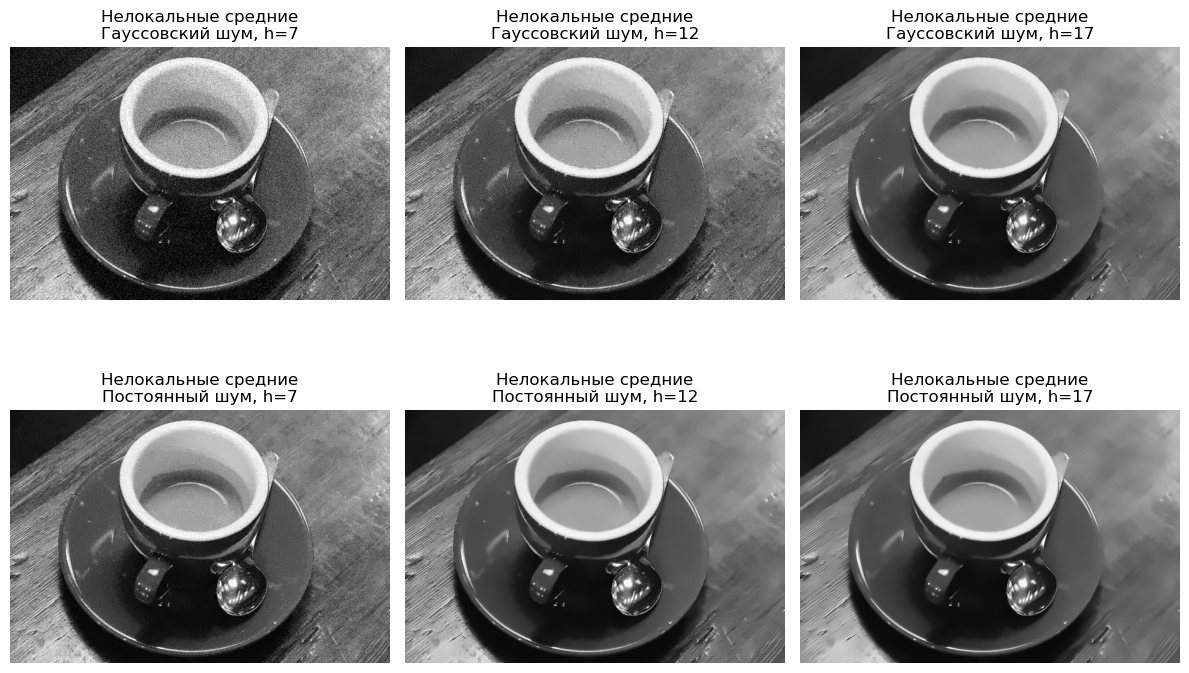

In [7]:


nlm_1 = cv2.fastNlMeansDenoising(gaussian_image, None, 7, 7, 21)
nlm_2 = cv2.fastNlMeansDenoising(gaussian_image, None, 12, 7, 21)
nlm_3 = cv2.fastNlMeansDenoising(gaussian_image, None, 17, 7, 21)

uniform_nlm_1 = cv2.fastNlMeansDenoising(uniform_image, None, 7, 7, 21)
uniform_nlm_2 = cv2.fastNlMeansDenoising(uniform_image, None, 12, 7, 21)
uniform_nlm_3 = cv2.fastNlMeansDenoising(uniform_image, None, 17, 7, 21)

plt.figure(figsize=(12, 8))
for i, (img, title) in enumerate([
    (nlm_1, 'Гауссовский шум, h=7'),
    (nlm_2, 'Гауссовский шум, h=12'),
    (nlm_3, 'Гауссовский шум, h=17'),
    (uniform_nlm_1, 'Постоянный шум, h=7'),
    (uniform_nlm_2, 'Постоянный шум, h=12'),
    (uniform_nlm_3, 'Постоянный шум, h=17')
], 1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap='gray')
    plt.title('Нелокальные средние\n' + title)
    plt.axis('off')
plt.tight_layout()
plt.show()

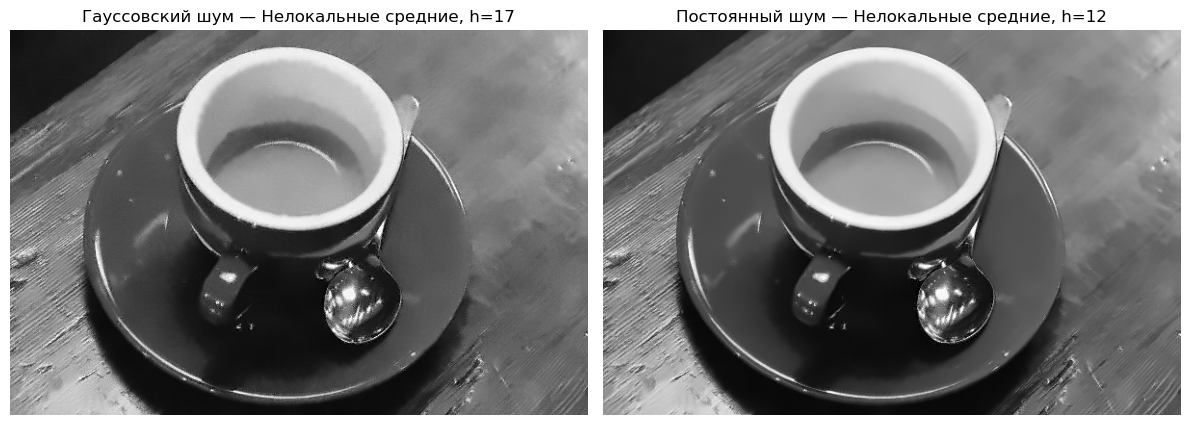

In [8]:
# Сравнение результатов

best_gaussian = nlm_3
best_uniform = uniform_nlm_2

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(best_gaussian, cmap='gray')
plt.title('Гауссовский шум — Нелокальные средние, h=17')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(best_uniform, cmap='gray')
plt.title('Постоянный шум — Нелокальные средние, h=12')
plt.axis('off')

plt.tight_layout()
plt.show()


### Вывод

В работе изображение было зашумлено гауссовским и постоянным шумом. Для каждого шума были протестированы медианный фильтр, фильтр Гаусса, билатеральный фильтр и фильтр нелокальных средних с различными параметрами. По результатам сравнения наиболее удачным оказался фильтр нелокальных средних: для гауссовского шума — при h=17, для постоянного шума — при h=12.